## 1. Imports and Setup

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.append('..')

# Import and force reload to pick up latest changes
import importlib
from prediction import delay_rules, feature_engineering, delay_model
importlib.reload(delay_rules)
importlib.reload(feature_engineering)
importlib.reload(delay_model)

from prediction.delay_rules import DelayRulesEstimator
from prediction.delay_model import DelayMLModel

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports complete!")

✅ Imports complete!


## 3. Generate or Load Synthetic Data

In [ ]:
# Paths
DATA_FILE = os.path.join("..", "data", "processed", "synthetic_delay_data.csv")
MODEL_DIR = os.path.join("..", "data", "models")

# Check if synthetic data exists
if not os.path.exists(DATA_FILE):
    print(f"Synthetic data not found at {DATA_FILE}")
    print("Generating synthetic data...")
    
    os.makedirs(os.path.dirname(DATA_FILE), exist_ok=True)
    
    estimator = DelayRulesEstimator(is_weekend=False)
    road_types = list(DelayRulesEstimator.ROAD_BASE_SPEED.keys())
    samples = []
    
    for _ in range(5000):
        samples.append({
            "road_type": random.choice(road_types),
            "length_m": random.uniform(50, 1500),
            "hour_of_day": random.randint(0, 23)
        })
    
    df = estimator.estimate_batch(samples)
    df.to_csv(DATA_FILE, index=False)
    print(f"Generated synthetic data at {DATA_FILE}")
else:
    print(f"Found existing data at {DATA_FILE}")

# Load data
print(f"\nLoading data...")
df = pd.read_csv(DATA_FILE)
print(f"   Dataset size: {len(df):,} samples")
print(f"   Columns: {list(df.columns)}")

# Display first few rows
df.head()

✅ Found existing data at ..\data\processed\synthetic_delay_data.csv

📂 Loading data...
   Dataset size: 5,000 samples
   Columns: ['road_type', 'length_m', 'hour_of_day', 'base_time_sec', 'observed_time_sec', 'delay_sec']


,road_type,length_m,hour_of_day,base_time_sec,observed_time_sec,delay_sec
0,residential,1054.524147,6,189.81,154.81,-35.00
1,primary,693.717327,12,55.50,62.27,6.77
2,primary,1092.958578,21,87.44,85.75,-1.68
3,motorway,662.800006,0,39.77,31.88,-7.88
4,secondary,430.271219,3,44.26,41.04,-3.22


## 4. Data Exploration

In [ ]:
# Basic statistics
print("Dataset Statistics:")
print(df.describe())

print("\nRoad Type Distribution:")
print(df['road_type'].value_counts())

📊 Dataset Statistics:
          length_m  hour_of_day  base_time_sec  observed_time_sec    delay_sec
count  5000.000000  5000.000000    5000.000000        5000.000000  5000.000000
mean    775.410309    11.318000     102.348954         115.113154    12.764192
std     419.686464     6.893125      73.862681          90.995988    37.390333
min      50.328724     0.000000       3.020000           2.510000   -75.570000
25%     406.071942     5.000000      44.847500          48.172500    -7.992500
50%     775.904566    11.000000      85.070000          91.760000     2.610000
75%    1136.777265    17.000000     143.885000         157.937500    23.560000
max    1499.090866    23.000000     359.480000         597.950000   252.280000

📊 Road Type Distribution:
road_type
unclassified    762
residential     730
primary         719
tertiary        717
secondary       713
service         686
motorway        673
Name: count, dtype: int64


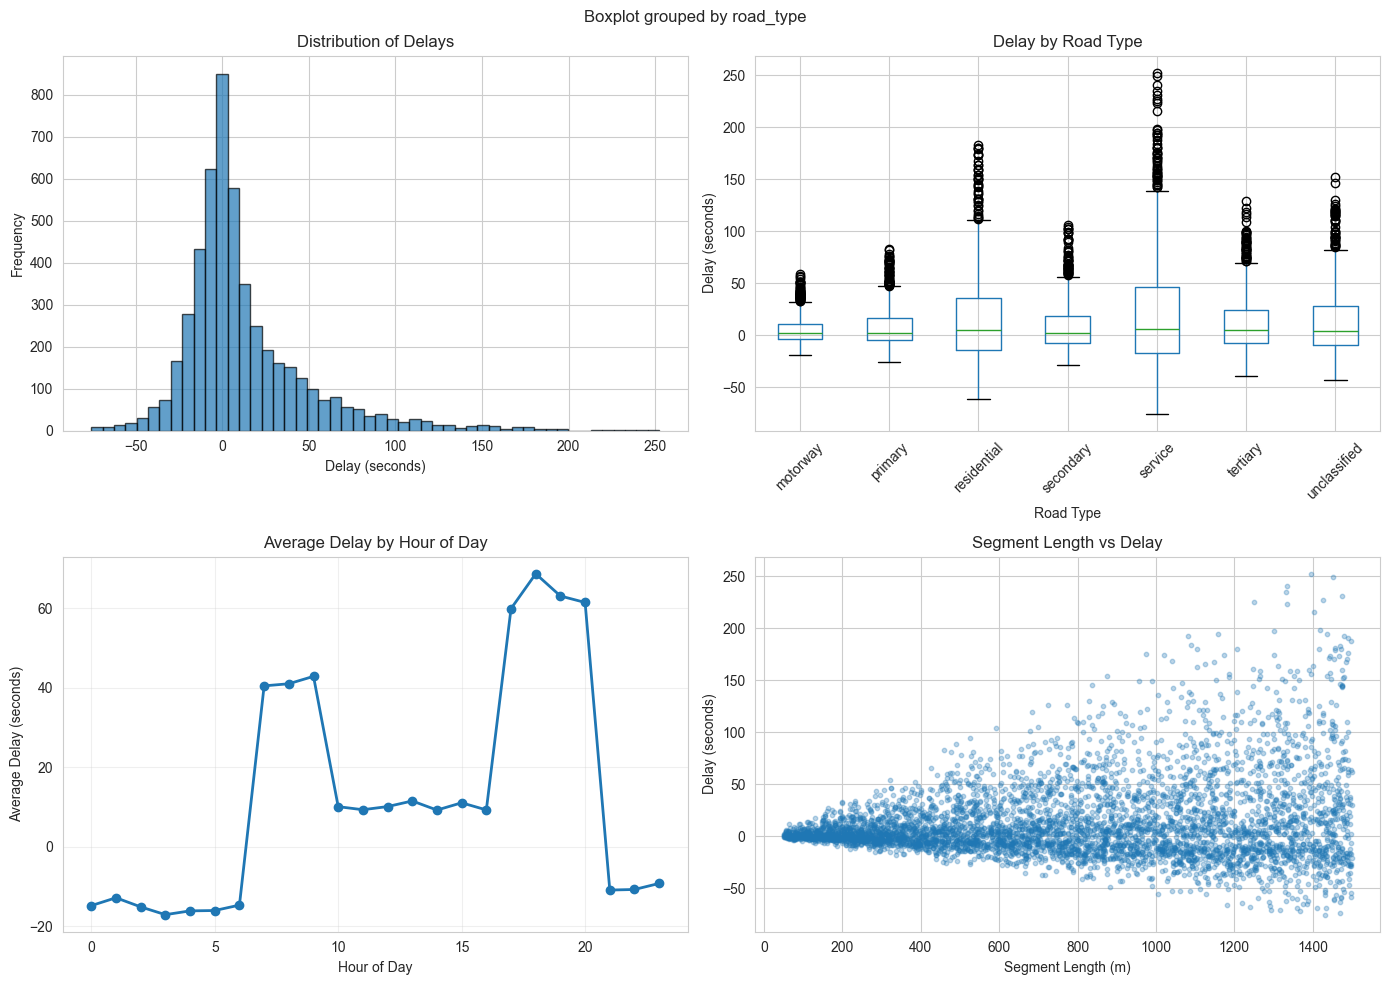

In [19]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Delay distribution
axes[0, 0].hist(df['delay_sec'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Delay (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Delays')

# Delay by road type
df.boxplot(column='delay_sec', by='road_type', ax=axes[0, 1])
axes[0, 1].set_xlabel('Road Type')
axes[0, 1].set_ylabel('Delay (seconds)')
axes[0, 1].set_title('Delay by Road Type')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# Delay by hour of day
hourly_delay = df.groupby('hour_of_day')['delay_sec'].mean()
axes[1, 0].plot(hourly_delay.index, hourly_delay.values, marker='o', linewidth=2)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Average Delay (seconds)')
axes[1, 0].set_title('Average Delay by Hour of Day')
axes[1, 0].grid(True, alpha=0.3)

# Length vs Delay scatter
axes[1, 1].scatter(df['length_m'], df['delay_sec'], alpha=0.3, s=10)
axes[1, 1].set_xlabel('Segment Length (m)')
axes[1, 1].set_ylabel('Delay (seconds)')
axes[1, 1].set_title('Segment Length vs Delay')

plt.tight_layout()
plt.show()

## 5. Train Linear Regression Model

In [20]:
# Train Linear Regression
print("="*60)
print("Training LINEAR REGRESSION model")
print("="*60)

lr_model = DelayMLModel(model_type="linear_regression")
lr_metrics = lr_model.train(df, test_size=0.2, use_cross_validation=True)

Training LINEAR REGRESSION model
🔧 Training linear_regression model...
✅ Training complete!

📊 Model Performance Metrics:
Metric               Train           Test           
--------------------------------------------------
MAE (seconds)        23.25           23.73          
RMSE (seconds)       32.12           33.47          
R² Score             0.245           0.261          
--------------------------------------------------
Cross-Validation MAE: 23.32 ± 0.89


In [21]:
# Save Linear Regression model
lr_model.save(MODEL_DIR, "delay_linear_regression")

✅ Model saved to ..\data\models/
   - delay_linear_regression.pkl
   - delay_linear_regression_feature_engineer.pkl


## 6. Train Random Forest Model

In [22]:
# Train Random Forest
print("="*60)
print("Training RANDOM FOREST model")
print("="*60)

rf_model = DelayMLModel(model_type="random_forest")
rf_metrics = rf_model.train(df, test_size=0.2, use_cross_validation=True)

Training RANDOM FOREST model
🔧 Training random_forest model...
✅ Training complete!

📊 Model Performance Metrics:
Metric               Train           Test           
--------------------------------------------------
MAE (seconds)        3.89            6.30           
RMSE (seconds)       5.93            9.59           
R² Score             0.974           0.939          
--------------------------------------------------
Cross-Validation MAE: 6.00 ± 0.18


In [ ]:
# Feature importance for Random Forest
print("\nFeature Importances:")
importance = rf_model.get_feature_importance()
for i, (feature, imp) in enumerate(importance.items()):
    print(f"   {i+1}. {feature}: {imp:.4f}")


🔍 Feature Importances:
   1. base_time_sec: 0.3802
   2. sin_hour: 0.3571
   3. cos_hour: 0.2509
   4. length_m: 0.0104
   5. road_type_2: 0.0004
   6. road_type_6: 0.0004
   7. road_type_5: 0.0002
   8. road_type_3: 0.0002
   9. road_type_4: 0.0002
   10. road_type_1: 0.0001
   11. road_type_0: 0.0000


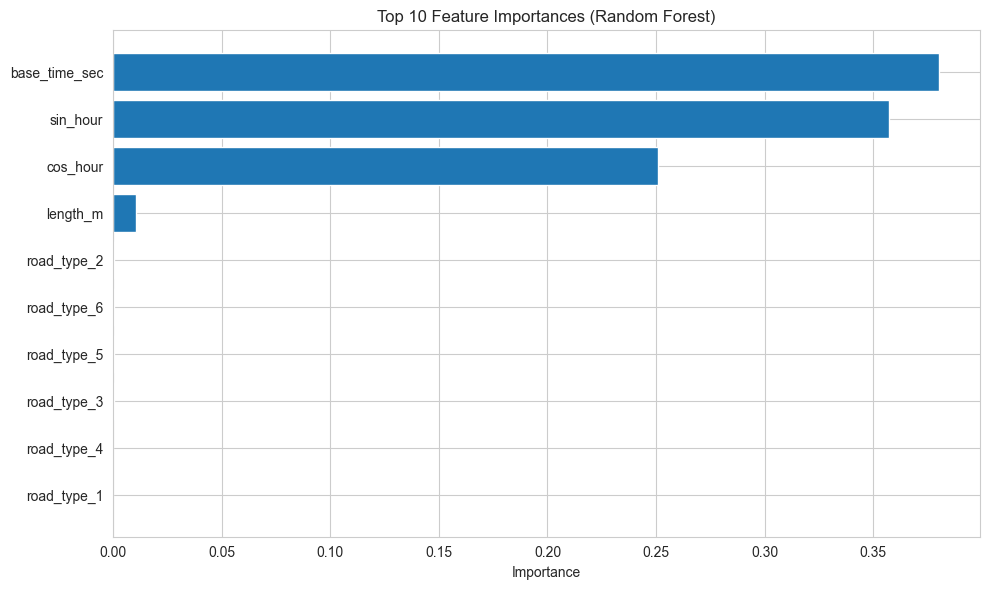

In [24]:
# Visualize feature importance
importance_df = pd.DataFrame([
    {'Feature': k, 'Importance': v} 
    for k, v in list(importance.items())[:10]
])

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# Save Random Forest model
rf_model.save(MODEL_DIR, "delay_random_forest")

✅ Model saved to ..\data\models/
   - delay_random_forest.pkl
   - delay_random_forest_feature_engineer.pkl


## 7. Model Comparison

In [ ]:
# Compare models
comparison_df = pd.DataFrame({
    'Metric': ['Test MAE', 'Test RMSE', 'Test R²', 'CV MAE'],
    'Linear Regression': [
        lr_metrics['test_mae'],
        lr_metrics['test_rmse'],
        lr_metrics['test_r2'],
        lr_metrics.get('cv_mae_mean', 0)
    ],
    'Random Forest': [
        rf_metrics['test_mae'],
        rf_metrics['test_rmse'],
        rf_metrics['test_r2'],
        rf_metrics.get('cv_mae_mean', 0)
    ]
})

print("\nModel Comparison:")
print(comparison_df.to_string(index=False))


📊 Model Comparison:
   Metric  Linear Regression  Random Forest
 Test MAE          23.734687       6.304814
Test RMSE          33.469107       9.593246
  Test R²           0.260820       0.939271
   CV MAE          23.321036       5.998029


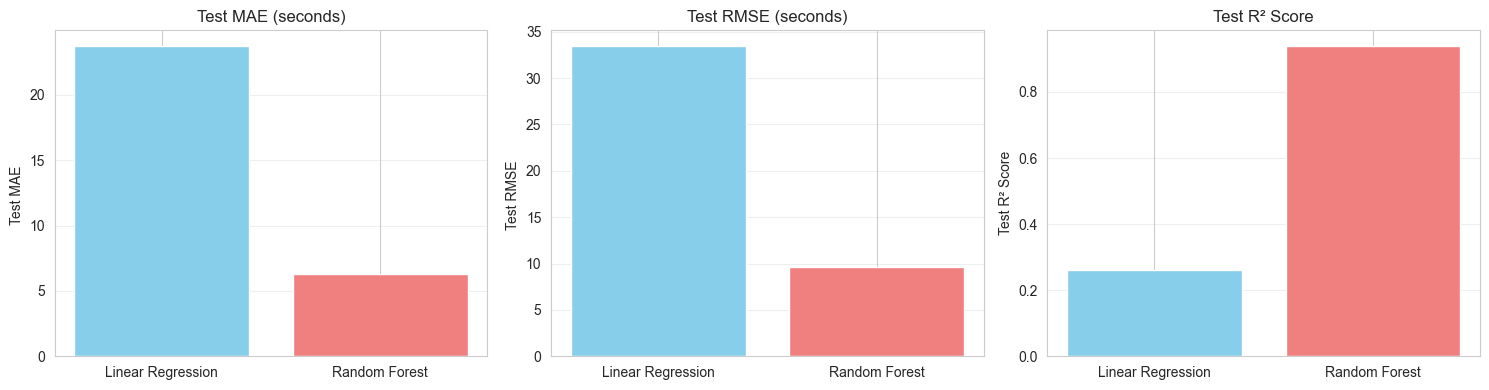

In [27]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['test_mae', 'test_rmse', 'test_r2']
titles = ['Test MAE (seconds)', 'Test RMSE (seconds)', 'Test R² Score']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = [lr_metrics[metric], rf_metrics[metric]]
    axes[i].bar(['Linear Regression', 'Random Forest'], values, 
                color=['skyblue', 'lightcoral'])
    axes[i].set_ylabel(title.split('(')[0])
    axes[i].set_title(title)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Test Predictions

In [ ]:
# Test single predictions
test_scenarios = [
    {"road_type": "motorway", "length_m": 1000, "hour_of_day": 9, "description": "Motorway at morning peak"},
    {"road_type": "primary", "length_m": 500, "hour_of_day": 9, "description": "Primary road at morning peak"},
    {"road_type": "residential", "length_m": 300, "hour_of_day": 12, "description": "Residential at midday"},
    {"road_type": "primary", "length_m": 500, "hour_of_day": 18, "description": "Primary road at evening peak"},
]

print("\nTest Predictions:")
print("=" * 80)
print(f"{'Scenario':<35} {'LR Delay':<15} {'RF Delay':<15}")
print("-" * 80)

for scenario in test_scenarios:
    lr_delay = lr_model.predict_single(
        scenario["road_type"],
        scenario["length_m"],
        scenario["hour_of_day"]
    )
    rf_delay = rf_model.predict_single(
        scenario["road_type"],
        scenario["length_m"],
        scenario["hour_of_day"]
    )
    
    print(f"{scenario['description']:<35} {lr_delay:<15.2f} {rf_delay:<15.2f}")

print("=" * 80)


🧪 Test Predictions:
Scenario                            LR Delay        RF Delay       
--------------------------------------------------------------------------------
Motorway at morning peak            6.02            25.32          
Primary road at morning peak        4.71            14.58          
Residential at midday               20.75           5.23           
Primary road at evening peak        21.61           23.52          


## 9. Summary and Conclusions

In [ ]:
print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"\nModels saved in: {MODEL_DIR}")
print("   - delay_linear_regression.pkl")
print("   - delay_linear_regression_feature_engineer.pkl")
print("   - delay_random_forest.pkl")
print("   - delay_random_forest_feature_engineer.pkl")
print("\nBest Model: ", end="")
if rf_metrics['test_r2'] > lr_metrics['test_r2']:
    print(f"Random Forest (R² = {rf_metrics['test_r2']:.3f})")
else:
    print(f"Linear Regression (R² = {lr_metrics['test_r2']:.3f})")
print("="*60)


✅ TRAINING COMPLETE!

📁 Models saved in: ..\data\models
   - delay_linear_regression.pkl
   - delay_linear_regression_feature_engineer.pkl
   - delay_random_forest.pkl
   - delay_random_forest_feature_engineer.pkl

🎯 Best Model: Random Forest (R² = 0.939)
